
Simulating nonlinear functional time series...
Total curves:                 500
Pre-forecast curves:          495
FAE training curves:          421
FAE validation curves:        74
Forecast/test curves:         5
Grid points per curve:        100
Latent dimension K:           5
Forecast horizon:             5

Scenario: one nonlinear latent VAR(2) variable controls phase shift and moving bump.


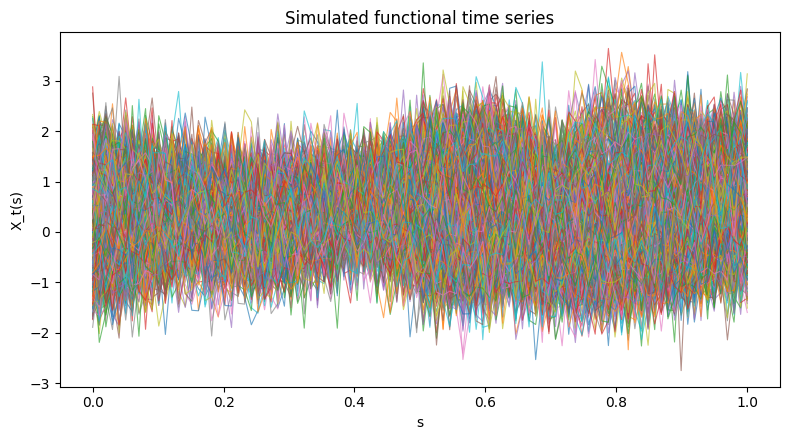


Training nonlinear FAE...
Epoch    1/300 | train_total=0.781267 | val_total=0.691393 | train_recon=0.771287 | val_recon=0.677911
Epoch  100/300 | train_total=0.235810 | val_total=0.241094 | train_recon=0.233663 | val_recon=0.239094
Epoch  200/300 | train_total=0.233951 | val_total=0.240017 | train_recon=0.231825 | val_recon=0.238082
Epoch  300/300 | train_total=0.233079 | val_total=0.240256 | train_recon=0.230790 | val_recon=0.238223


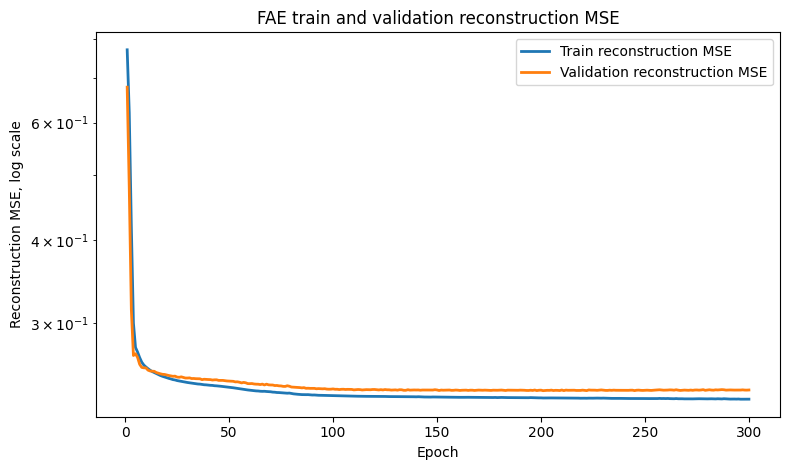


FAE reconstruction MSE on centered noisy scale
Pre-forecast full sample: 0.231756
Final 5 test curves:     0.246467

Fitting time-series model to FAE latent scores...
FAE score model: VAR(5)
FAE score AIC:   -8.451686

Fitting FPCA and time-series model to FPCA scores...

FPCA reconstruction MSE on centered noisy scale
Pre-forecast full sample: 0.229858
Explained variance with K=5: 0.7114
FPCA score model: VAR(5)
FPCA score AIC:   -7.776079

Forecasting results
            Target           Method      MSE     RMSE   relMSE
       Clean truth FAE + latent VAR 0.007004 0.083687 0.007728
       Clean truth FPCA + score VAR 0.041538 0.203808 0.045836
Noisy observations FAE + latent VAR 0.258618 0.508545 0.235677
Noisy observations FPCA + score VAR 0.283399 0.532352 0.258260

Clean-truth comparison
FAE improves over FPCA by about 83.1% in MSE.


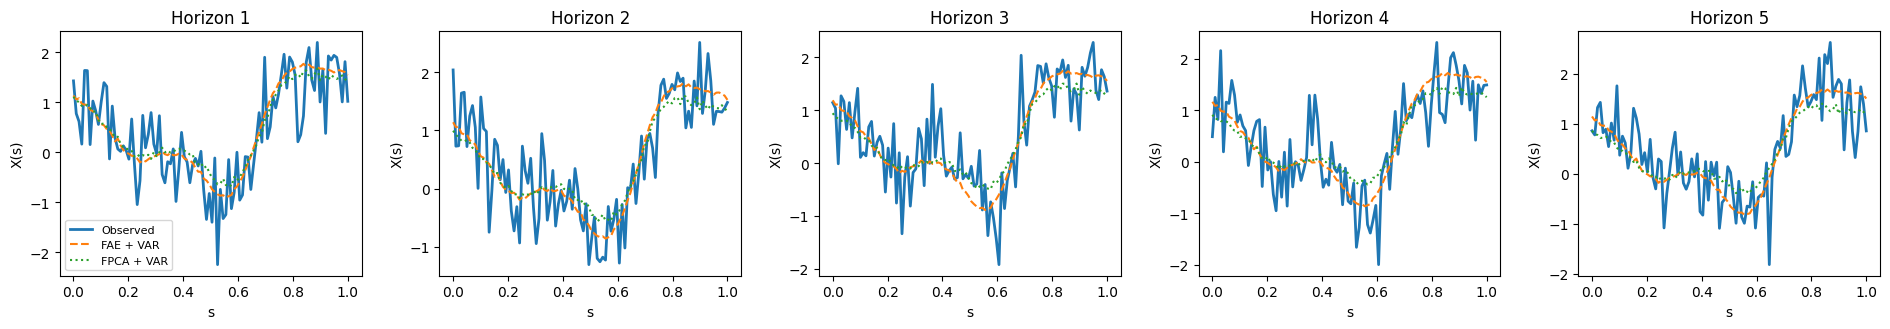

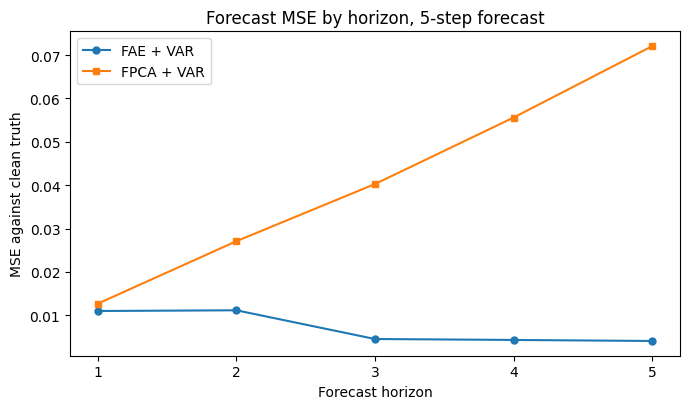

In [ ]:
"""
Nonlinear 1D latent functional time-series simulation:
FAE + score forecasting versus FPCA + score forecasting.
"""

from __future__ import annotations

import random
from dataclasses import dataclass
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.interpolate import BSpline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from torch import optim
from torch.utils.data import DataLoader, TensorDataset


@dataclass
class Config:
    n_time: int = 500
    n_grid: int = 100

    # Forecast horizon is now 5.
    forecast_horizon: int = 5

    noise_sd: float = 0.5

    # Latent dimension for FAE and FPCA.
    latent_dim: int = 5

    n_basis: int = 35
    hidden_width: int = 64
    epochs: int = 300
    batch_size: int = 64
    learning_rate: float = 1e-3
    weight_decay: float = 1e-6
    smooth_lambda: float = 0.01

    # Validation split taken chronologically from the end of the pre-forecast sample.
    validation_fraction: float = 0.15

    max_ar_lags: int = 8
    seed: int = 743


CFG = Config()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(1)


# ============================================================
# Simulation
# ============================================================

def simulate_latent_ar1(n_time: int, seed: int) -> np.ndarray:
    """
    Smooth one-dimensional AR(2) latent process with oscillatory dynamics.

    The nonlinear part of the simulation is the map from z_t to X_t(s),
    not the time-series model.
    """
    rng = np.random.default_rng(seed)
    burn = 200

    period = 90.0
    omega = 2.0 * np.pi / period
    rho = 0.995
    a1 = 2.0 * rho * np.cos(omega)
    a2 = -rho ** 2
    innovation_sd = 0.025

    z = np.zeros(n_time + burn)
    z[0] = rng.normal()
    z[1] = rng.normal()

    for t in range(2, n_time + burn):
        z[t] = a1 * z[t - 1] + a2 * z[t - 2] + rng.normal(0.0, innovation_sd)

    z = z[burn:]
    z = (z - z.mean()) / z.std()

    return z.reshape(-1, 1).astype(np.float32)


def nonlinear_curve_decoder(z: np.ndarray, s: np.ndarray) -> np.ndarray:
    """
    Nonlinear 1D latent-to-curve map.

    The main nonlinear difficulty is phase variation and a moving bump.
    """
    z1 = z[:, 0]
    n_time = len(z1)
    n_grid = len(s)
    x = np.zeros((n_time, n_grid), dtype=np.float32)

    mean_curve = 0.20 + 0.35 * s - 0.10 * (s - 0.5) ** 2

    for t in range(n_time):
        phase = 0.32 * np.tanh(1.10 * z1[t])
        center = 0.50 + 0.28 * np.tanh(0.90 * z1[t])
        height = 0.85 * np.tanh(1.20 * z1[t])
        width = 0.060

        bump = height * np.exp(-0.5 * ((s - center) / width) ** 2)
        wave1 = np.sin(2.0 * np.pi * (s + phase))
        wave2 = 0.40 * np.cos(4.0 * np.pi * (s + 0.45 * phase))
        wave3 = 0.18 * np.sin(6.0 * np.pi * s) * np.tanh(z1[t])

        x[t] = mean_curve + wave1 + wave2 + wave3 + bump

    return x


def simulate_functional_ts(
    cfg: Config,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    s = np.linspace(0.0, 1.0, cfg.n_grid)

    z = simulate_latent_ar1(cfg.n_time, cfg.seed)
    x_clean = nonlinear_curve_decoder(z, s)

    rng = np.random.default_rng(cfg.seed + 1000)
    x_noisy = x_clean + rng.normal(
        0.0,
        cfg.noise_sd,
        size=x_clean.shape,
    ).astype(np.float32)

    return (
        s.astype(np.float32),
        x_clean.astype(np.float32),
        x_noisy.astype(np.float32),
        z.astype(np.float32),
    )


# ============================================================
# Basis and nonlinear FAE
# ============================================================

def make_bspline_basis(
    t_grid: np.ndarray,
    n_basis: int,
    degree: int = 3,
) -> torch.Tensor:
    t_grid = np.asarray(t_grid, dtype=float)
    a, b = float(t_grid.min()), float(t_grid.max())

    if n_basis <= degree:
        raise ValueError("n_basis must be larger than degree.")

    n_interior = n_basis - degree - 1

    if n_interior > 0:
        interior = np.linspace(a, b, n_interior + 2)[1:-1]
    else:
        interior = np.array([])

    knots = np.concatenate([
        np.repeat(a, degree + 1),
        interior,
        np.repeat(b, degree + 1),
    ])

    basis = []

    for i in range(n_basis):
        c = np.zeros(n_basis)
        c[i] = 1.0

        spline = BSpline(knots, c, degree, extrapolate=False)
        values = spline(t_grid)
        values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)

        basis.append(values)

    return torch.tensor(np.vstack(basis), dtype=torch.float32)


class NonlinearFAE(nn.Module):
    """Grid input -> nonlinear encoder -> latent -> nonlinear decoder -> B-spline curve."""

    def __init__(
        self,
        n_grid: int,
        latent_dim: int,
        hidden_width: int,
        n_basis: int,
        basis: torch.Tensor,
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(n_grid, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, latent_dim),
        )

        self.decoder_to_coef = nn.Sequential(
            nn.Linear(latent_dim, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, hidden_width),
            nn.Tanh(),
            nn.Linear(hidden_width, n_basis),
        )

        self.register_buffer("basis", basis)

    def decode_latent(self, h: torch.Tensor):
        coef = self.decoder_to_coef(h)
        x_hat = torch.matmul(coef, self.basis)
        return x_hat, coef

    def forward(self, x: torch.Tensor):
        h = self.encoder(x)
        x_hat, coef = self.decode_latent(h)
        return x_hat, h, coef


# ============================================================
# Training and prediction
# ============================================================

def chronological_train_validation_split(
    data: np.ndarray,
    validation_fraction: float,
) -> Tuple[np.ndarray, np.ndarray]:
    n_total = data.shape[0]
    n_val = int(round(validation_fraction * n_total))
    n_val = max(1, n_val)
    n_val = min(n_val, n_total - 1)

    train_data = data[:-n_val]
    val_data = data[-n_val:]

    return train_data, val_data


def fae_batch_losses(
    model: nn.Module,
    batch: torch.Tensor,
    cfg: Config,
    mse_loss: nn.Module,
):
    x_hat, h, coef = model(batch)

    recon_loss = mse_loss(x_hat, batch)

    second_diff = coef[:, 2:] - 2.0 * coef[:, 1:-1] + coef[:, :-2]
    smooth_penalty = torch.mean(torch.sum(second_diff ** 2, dim=1))

    total_loss = recon_loss + cfg.smooth_lambda * smooth_penalty

    return total_loss, recon_loss, smooth_penalty


def evaluate_fae_loss(
    model: nn.Module,
    data: torch.Tensor,
    cfg: Config,
    device: torch.device,
) -> Tuple[float, float, float]:
    loader = DataLoader(
        TensorDataset(data),
        batch_size=cfg.batch_size,
        shuffle=False,
        drop_last=False,
    )

    mse_loss = nn.MSELoss()

    total_loss_sum = 0.0
    recon_loss_sum = 0.0
    smooth_sum = 0.0
    n_seen = 0

    model.eval()

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)

            total_loss, recon_loss, smooth_penalty = fae_batch_losses(
                model,
                batch,
                cfg,
                mse_loss,
            )

            bs = batch.shape[0]

            total_loss_sum += total_loss.item() * bs
            recon_loss_sum += recon_loss.item() * bs
            smooth_sum += smooth_penalty.item() * bs
            n_seen += bs

    return (
        total_loss_sum / n_seen,
        recon_loss_sum / n_seen,
        smooth_sum / n_seen,
    )


def train_fae(
    model: nn.Module,
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    cfg: Config,
    device: torch.device,
) -> pd.DataFrame:
    loader = DataLoader(
        TensorDataset(train_data),
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=False,
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )

    mse_loss = nn.MSELoss()
    history = []

    for epoch in range(1, cfg.epochs + 1):
        model.train()

        train_total_sum = 0.0
        train_recon_sum = 0.0
        train_smooth_sum = 0.0
        n_seen = 0

        for (batch,) in loader:
            batch = batch.to(device)

            optimizer.zero_grad()

            total_loss, recon_loss, smooth_penalty = fae_batch_losses(
                model,
                batch,
                cfg,
                mse_loss,
            )

            total_loss.backward()
            optimizer.step()

            bs = batch.shape[0]

            train_total_sum += total_loss.item() * bs
            train_recon_sum += recon_loss.item() * bs
            train_smooth_sum += smooth_penalty.item() * bs
            n_seen += bs

        train_total = train_total_sum / n_seen
        train_recon = train_recon_sum / n_seen
        train_smooth = train_smooth_sum / n_seen

        val_total, val_recon, val_smooth = evaluate_fae_loss(
            model,
            val_data,
            cfg,
            device,
        )

        history.append({
            "epoch": epoch,
            "train_total": train_total,
            "train_recon": train_recon,
            "train_smooth": train_smooth,
            "val_total": val_total,
            "val_recon": val_recon,
            "val_smooth": val_smooth,
        })

        if epoch == 1 or epoch % 100 == 0 or epoch == cfg.epochs:
            print(
                f"Epoch {epoch:4d}/{cfg.epochs} | "
                f"train_total={train_total:.6f} | "
                f"val_total={val_total:.6f} | "
                f"train_recon={train_recon:.6f} | "
                f"val_recon={val_recon:.6f}"
            )

    return pd.DataFrame(history)


def predict_fae(
    model: nn.Module,
    data: torch.Tensor,
    device: torch.device,
):
    model.eval()

    with torch.no_grad():
        data = data.to(device)
        x_hat, h, coef = model(data)
        recon_mse = torch.mean((x_hat - data) ** 2).item()

    return x_hat.cpu(), h.cpu(), coef.cpu(), recon_mse


# ============================================================
# Score forecasting: AR for K=1, VAR for K>1
# ============================================================

def forecast_scores_time_series(
    scores_train: np.ndarray,
    horizon: int,
    maxlags: int,
):
    """
    Same forecasting helper for FAE latents and FPCA scores.

    If K=1:
        use univariate AR(p) selected by AIC.

    If K>1:
        use VAR(p) selected by AIC.
    """
    scaler = StandardScaler()
    scores_std = scaler.fit_transform(scores_train)

    n, k = scores_std.shape

    if k == 1:
        y = scores_std[:, 0]
        maxlags = min(maxlags, max(1, n // 8))

        best_result = None
        best_aic = np.inf
        best_lag = None

        for lag in range(1, maxlags + 1):
            try:
                result = AutoReg(y, lags=lag, old_names=False).fit()

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_result = result
                    best_lag = lag

            except Exception:
                continue

        if best_result is None:
            raise RuntimeError("AR fitting failed for all lag choices.")

        forecast_std = best_result.predict(
            start=n,
            end=n + horizon - 1,
        ).reshape(-1, 1)

        forecast = scaler.inverse_transform(forecast_std)

        info = {
            "model": "AR",
            "lag": best_lag,
            "aic": best_aic,
        }

        return forecast, info, scaler

    safe_maxlags = min(maxlags, max(1, (n - 2) // (k + 1)))
    safe_maxlags = max(1, safe_maxlags)

    last_error = None

    for pmax in range(safe_maxlags, 0, -1):
        try:
            model = VAR(scores_std)
            result = model.fit(maxlags=pmax, ic="aic")

            if result.k_ar == 0:
                result = model.fit(1)

            p = result.k_ar

            forecast_std = result.forecast(scores_std[-p:], steps=horizon)
            forecast = scaler.inverse_transform(forecast_std)

            info = {
                "model": "VAR",
                "lag": p,
                "aic": result.aic,
            }

            return forecast, info, scaler

        except Exception as err:
            last_error = err

    raise RuntimeError(f"VAR fitting failed. Last error: {last_error}")


# ============================================================
# FPCA + score forecasting baseline
# ============================================================

def fpca_score_forecast(
    train_centered: np.ndarray,
    horizon: int,
    latent_dim: int,
    maxlags: int,
):
    pca = PCA(n_components=latent_dim)

    scores_train = pca.fit_transform(train_centered)

    scores_forecast, info, scaler = forecast_scores_time_series(
        scores_train,
        horizon,
        maxlags,
    )

    forecast_centered = pca.inverse_transform(scores_forecast)
    recon_train_centered = pca.inverse_transform(scores_train)

    return {
        "forecast_centered": forecast_centered,
        "recon_train_centered": recon_train_centered,
        "scores_train": scores_train,
        "scores_forecast": scores_forecast,
        "pca": pca,
        "forecast_info": info,
    }


# ============================================================
# Metrics
# ============================================================

def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()

    return np.asarray(x)


def mse(pred, truth) -> float:
    pred = to_numpy(pred)
    truth = to_numpy(truth)

    return float(np.mean((pred - truth) ** 2))


def rmse(pred, truth) -> float:
    return float(np.sqrt(mse(pred, truth)))


def relative_mse(pred, truth) -> float:
    pred = to_numpy(pred)
    truth = to_numpy(truth)

    denom = np.mean(truth ** 2)

    return float(np.mean((pred - truth) ** 2) / denom)


def metric_table(
    fae_forecast,
    fpca_forecast,
    truth,
    target_name: str,
) -> pd.DataFrame:
    rows = []

    for method, pred in [
        ("FAE + latent VAR", fae_forecast),
        ("FPCA + score VAR", fpca_forecast),
    ]:
        rows.append({
            "Target": target_name,
            "Method": method,
            "MSE": mse(pred, truth),
            "RMSE": rmse(pred, truth),
            "relMSE": relative_mse(pred, truth),
        })

    return pd.DataFrame(rows)


# ============================================================
# Plotting
# ============================================================

def plot_simulated_curves(
    s,
    x,
    n_plot: int = 35,
    title: str = "Simulated functional time series",
):
    plt.figure(figsize=(8, 4.5))

    idx = np.linspace(
        0,
        x.shape[0] - 1,
        n_plot,
        dtype=int,
    )

    for i in idx:
        plt.plot(s, x[i], linewidth=0.8, alpha=0.65)

    plt.xlabel("s")
    plt.ylabel("X_t(s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_latent_process(z_true):
    plt.figure(figsize=(8, 3.5))

    plt.plot(z_true[:, 0], linewidth=1.5)

    plt.xlabel("Time index")
    plt.ylabel("True latent z_t")
    plt.title("True simulated latent process")
    plt.tight_layout()
    plt.show()


def plot_training_validation_losses(history: pd.DataFrame):
    plt.figure(figsize=(8, 4.8))

    epoch = history["epoch"].to_numpy()

    plt.plot(
        epoch,
        history["train_recon"],
        label="Train reconstruction MSE",
        linewidth=2,
    )

    plt.plot(
        epoch,
        history["val_recon"],
        label="Validation reconstruction MSE",
        linewidth=2,
    )

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Reconstruction MSE, log scale")
    plt.title("FAE train and validation reconstruction MSE")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_forecast_curves(
    s,
    truth,
    fae_forecast,
    fpca_forecast,
):
    """
    With forecast_horizon=5, this plots all 5 forecast curves.
    """
    n_plot = truth.shape[0]

    n_cols = n_plot
    n_rows = 1

    plt.figure(figsize=(3.8 * n_cols, 3.4 * n_rows))

    for i in range(n_plot):
        ax = plt.subplot(n_rows, n_cols, i + 1)

        ax.plot(
            s,
            truth[i],
            label="Observed",
            linewidth=2,
        )

        ax.plot(
            s,
            fae_forecast[i],
            linestyle="--",
            label="FAE + VAR",
        )

        ax.plot(
            s,
            fpca_forecast[i],
            linestyle=":",
            label="FPCA + VAR",
        )

        ax.set_title(f"Horizon {i + 1}")
        ax.set_xlabel("s")
        ax.set_ylabel("X(s)")

        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_mse_by_horizon(
    truth,
    fae_forecast,
    fpca_forecast,
):
    fae_h = np.mean((fae_forecast - truth) ** 2, axis=1)
    fpca_h = np.mean((fpca_forecast - truth) ** 2, axis=1)

    horizon = np.arange(1, len(fae_h) + 1)

    plt.figure(figsize=(7, 4.2))

    plt.plot(
        horizon,
        fae_h,
        marker="o",
        markersize=5,
        label="FAE + VAR",
    )

    plt.plot(
        horizon,
        fpca_h,
        marker="s",
        markersize=5,
        label="FPCA + VAR",
    )

    plt.xticks(horizon)
    plt.xlabel("Forecast horizon")
    plt.ylabel("MSE against clean truth")
    plt.title("Forecast MSE by horizon, 5-step forecast")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_overall_mse(summary_clean):
    plt.figure(figsize=(6, 4))

    plt.bar(summary_clean["Method"], summary_clean["MSE"])

    plt.ylabel("MSE against clean truth")
    plt.title("Overall 5-step forecast MSE")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


def plot_score_forecasts(
    train_scores,
    forecast_scores,
    title: str,
    context_window: int = 80,
):
    """
    Shows only the last part of the training score series so the 5-step
    forecast is visually meaningful instead of being compressed at the end
    of a long 500-point plot.
    """
    T = len(train_scores)
    L = len(forecast_scores)

    start = max(0, T - context_window)

    train_x = np.arange(start, T)
    forecast_x = np.arange(T, T + L)

    plt.figure(figsize=(8, 3.8))

    plt.plot(
        train_x,
        train_scores[start:T, 0],
        label=f"Last {T - start} training scores",
    )

    plt.plot(
        forecast_x,
        forecast_scores[:, 0],
        marker="o",
        linestyle="--",
        label=f"{L}-step forecast score",
    )

    plt.axvline(T - 1, linestyle=":")

    plt.xlabel("Time index")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Main
# ============================================================

def main() -> None:
    set_seed(CFG.seed)

    device = torch.device("cpu")

    print("\nSimulating nonlinear functional time series...")
    s, x_clean, x_noisy, z_true = simulate_functional_ts(CFG)

    L = CFG.forecast_horizon

    # Last L curves are the 5-step forecast/test period.
    train_noisy_full = x_noisy[:-L]
    test_noisy = x_noisy[-L:]

    train_clean_full = x_clean[:-L]
    test_clean = x_clean[-L:]

    # Center using the full pre-forecast period.
    # No information from the final 5 test curves is used here.
    train_mean = train_noisy_full.mean(axis=0, keepdims=True)

    train_centered_full = train_noisy_full - train_mean
    test_centered = test_noisy - train_mean

    # Chronological validation split for FAE training curves.
    fae_train_centered, fae_val_centered = chronological_train_validation_split(
        train_centered_full,
        CFG.validation_fraction,
    )

    print(f"Total curves:                 {CFG.n_time}")
    print(f"Pre-forecast curves:          {train_centered_full.shape[0]}")
    print(f"FAE training curves:          {fae_train_centered.shape[0]}")
    print(f"FAE validation curves:        {fae_val_centered.shape[0]}")
    print(f"Forecast/test curves:         {L}")
    print(f"Grid points per curve:        {CFG.n_grid}")
    print(f"Latent dimension K:           {CFG.latent_dim}")
    print(f"Forecast horizon:             {CFG.forecast_horizon}")
    print("\nScenario: one nonlinear latent VAR(2) variable controls phase shift and moving bump.")

    plot_simulated_curves(s, x_noisy, n_plot=CFG.n_time)
    #plot_latent_process(z_true)

    # -----------------------------
    # FAE + VAR
    # -----------------------------

    print("\nTraining nonlinear FAE...")

    basis = make_bspline_basis(s, CFG.n_basis)

    fae = NonlinearFAE(
        n_grid=CFG.n_grid,
        latent_dim=CFG.latent_dim,
        hidden_width=CFG.hidden_width,
        n_basis=CFG.n_basis,
        basis=basis,
    ).to(device)

    fae_train_tensor = torch.tensor(fae_train_centered, dtype=torch.float32)
    fae_val_tensor = torch.tensor(fae_val_centered, dtype=torch.float32)
    train_full_tensor = torch.tensor(train_centered_full, dtype=torch.float32)
    test_tensor = torch.tensor(test_centered, dtype=torch.float32)

    history = train_fae(
        fae,
        fae_train_tensor,
        fae_val_tensor,
        CFG,
        device,
    )

    plot_training_validation_losses(history)

    recon_train_fae, H_train_torch, _, fae_recon_train_mse = predict_fae(
        fae,
        train_full_tensor,
        device,
    )

    recon_test_fae, H_test_torch, _, fae_recon_test_mse = predict_fae(
        fae,
        test_tensor,
        device,
    )

    H_train = H_train_torch.detach().cpu().numpy()

    print("\nFAE reconstruction MSE on centered noisy scale")
    print(f"Pre-forecast full sample: {fae_recon_train_mse:.6f}")
    print(f"Final 5 test curves:     {fae_recon_test_mse:.6f}")

    print("\nFitting time-series model to FAE latent scores...")

    H_forecast, fae_forecast_info, _ = forecast_scores_time_series(
        H_train,
        L,
        CFG.max_ar_lags,
    )

    print(
        f"FAE score model: "
        f"{fae_forecast_info['model']}({fae_forecast_info['lag']})"
    )
    print(f"FAE score AIC:   {fae_forecast_info['aic']:.6f}")

    fae.eval()

    with torch.no_grad():
        H_forecast_torch = torch.tensor(
            H_forecast,
            dtype=torch.float32,
        ).to(device)

        fae_forecast_centered_torch, _ = fae.decode_latent(H_forecast_torch)

        fae_forecast_centered = (
            fae_forecast_centered_torch
            .detach()
            .cpu()
            .numpy()
        )

    fae_forecast = fae_forecast_centered + train_mean

    # -----------------------------
    # FPCA + VAR
    # -----------------------------

    print("\nFitting FPCA and time-series model to FPCA scores...")

    fpca_out = fpca_score_forecast(
        train_centered_full,
        L,
        CFG.latent_dim,
        CFG.max_ar_lags,
    )

    fpca_forecast = fpca_out["forecast_centered"] + train_mean

    fpca_recon_train_mse = mse(
        fpca_out["recon_train_centered"],
        train_centered_full,
    )

    fpca_explained = float(
        np.sum(fpca_out["pca"].explained_variance_ratio_)
    )

    print("\nFPCA reconstruction MSE on centered noisy scale")
    print(f"Pre-forecast full sample: {fpca_recon_train_mse:.6f}")
    print(f"Explained variance with K={CFG.latent_dim}: {fpca_explained:.4f}")
    print(
        f"FPCA score model: "
        f"{fpca_out['forecast_info']['model']}({fpca_out['forecast_info']['lag']})"
    )
    print(f"FPCA score AIC:   {fpca_out['forecast_info']['aic']:.6f}")

    # -----------------------------
    # Evaluation
    # -----------------------------

    summary_clean = metric_table(
        fae_forecast,
        fpca_forecast,
        test_clean,
        "Clean truth",
    )

    summary_noisy = metric_table(
        fae_forecast,
        fpca_forecast,
        test_noisy,
        "Noisy observations",
    )

    summary = pd.concat(
        [summary_clean, summary_noisy],
        ignore_index=True,
    )

    print("\nForecasting results")
    print(summary.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    fae_clean_mse = summary_clean.loc[
        summary_clean["Method"] == "FAE + latent VAR",
        "MSE",
    ].iloc[0]

    fpca_clean_mse = summary_clean.loc[
        summary_clean["Method"] == "FPCA + score VAR",
        "MSE",
    ].iloc[0]

    improvement = 100.0 * (1.0 - fae_clean_mse / fpca_clean_mse)

    print("\nClean-truth comparison")

    if improvement > 0:
        print(f"FAE improves over FPCA by about {improvement:.1f}% in MSE.")
    else:
        print(f"FPCA is better in this run by about {-improvement:.1f}% in MSE.")

    # -----------------------------
    # Plots only. Nothing is saved.
    # -----------------------------

    #plot_score_forecasts(
    #    H_train,
    #    H_forecast,
    #    "FAE latent score forecast, last training window plus 5-step forecast",
    #)

    #plot_score_forecasts(
    #    fpca_out["scores_train"],
    #    fpca_out["scores_forecast"],
    #    "FPCA score forecast, last training window plus 5-step forecast",
    #)

    plot_forecast_curves(
        s,
        test_noisy,
        fae_forecast,
        fpca_forecast,
    )

    plot_mse_by_horizon(
        test_clean,
        fae_forecast,
        fpca_forecast,
    )

    #plot_overall_mse(summary_clean)


if __name__ == "__main__":
    main()